## CDR x Climate Data

In this notebook, we are trying to map out the monhtly climate values for the spatial units used by CDR people.

In [1]:
# reload to load packages
%load_ext autoreload
%autoreload 2

In [2]:
# read the spatial units
import geopandas as gpd
import xarray as xr
import numpy as np
import rioxarray as rio
import pandas as pd
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from chord import Chord
import xvec
# import pyarrow

# import xesmf as xe

import warnings
warnings.filterwarnings('ignore')


### Description

We have climate data available from 2010 until 2025. In the following section, we are trying to make mini cubes of each climate variable and then do spatial and temporal aggregation. 

 - **Spatial Aggregation**: It will be based on the spatial units made available by @Paul from his CDR research
 - **Temporal Aggregation**: This will be done to make it consistent with CDR data. 

CDR data has half month index we are going for the half-month temporal resolution to avoid discrepancies.


## 1. Vector Data (Boundaries)

We only have CDR and spatial units of `Senegal`, therefore, the aggregation and the mini-cube will be closer to Senegal. However, towards the end of the notebook, we will see some more examples of the greater `Sahel Region`.

In [3]:
# senegal_boundaries = gpd.read_file('/home/kzakir/dvcube/cdrxclimate/cdr_test/spatial_units_SciData.gpkg')
# sahel_boundaries = gpd.read_file('/home/kzakir/dvcube/sah_admin0_ocha/sah_admin0_ocha.shp')
# sahel_boundaries = sahel_boundaries.to_crs("EPSG:4326")
# senegal_boundaries = senegal_boundaries.to_crs("EPSG:4326")
# print(sahel_boundaries)
# print(senegal_boundaries)

spatial_unit = gpd.read_parquet("/home/kzakir/dvcube/test/data/mobility_data/spatial_units.parquet")
spatial_unit

,id,name,zone_category,geometry,norm_id
0,SEN.1.1.1-rural,Dakar-rural,rural,"MULTIPOLYGON (((-17.14005 14.57827, -17.14034 ...",sen.1.1.1
1,SEN.10.1.1-rural,Mbane-rural,rural,"MULTIPOLYGON (((-15.83737 16.21078, -15.87214 ...",sen.10.1.1
2,SEN.10.1.2-rural,Ndiaye Mberess-rural,rural,"MULTIPOLYGON (((-16.26705 16.0281, -16.24896 1...",sen.10.1.2
3,SEN.10.2.1-rural,Cas Cas-rural,rural,"MULTIPOLYGON (((-14.37828 16.01092, -14.44253 ...",sen.10.2.1
4,SEN.10.2.2-rural,Gamadji Sarre-rural,rural,"MULTIPOLYGON (((-15.03611 16.01448, -14.99439 ...",sen.10.2.2
...,...,...,...,...,...
146,city-048,Thiès,urban,"MULTIPOLYGON (((-17.00244 14.80395, -17.0009 1...",city-048
147,city-049,Tivaouane,urban,"MULTIPOLYGON (((-16.8533 14.93582, -16.8485 14...",city-049
148,city-050,Touba,urban,"MULTIPOLYGON (((-15.92335 14.7155, -15.95312 1...",city-050
149,city-052,Vélingara,urban,"MULTIPOLYGON (((-14.1644 13.10737, -14.18021 1...",city-052


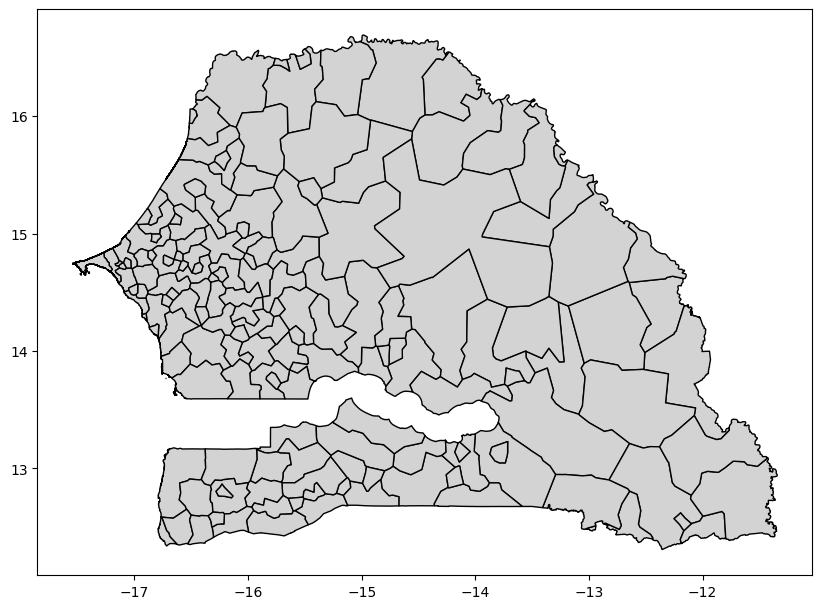

In [ ]:
# plot the spatial units
fig, ax = plt.subplots(figsize=(10, 10))
spatial_unit.plot(ax=ax, color='lightgrey', edgecolor='black')
minx, miny, maxx, maxy = spatial_unit.total_bounds


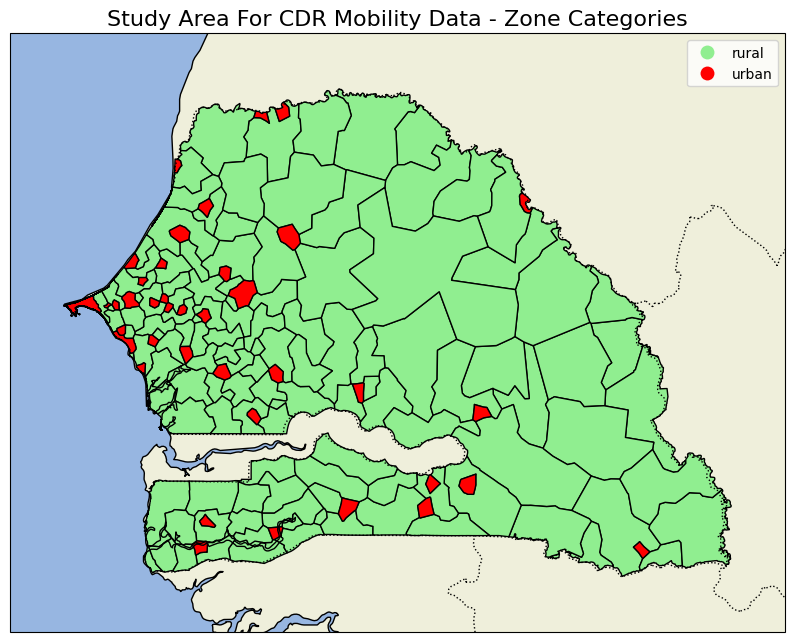

In [36]:
# plot the spatial units with cartopy with zone_category colors
from matplotlib.colors import ListedColormap
minx, miny, maxx, maxy = spatial_unit.total_bounds
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

cmap = ListedColormap(['lightgreen', 'red'])
spatial_unit.plot(ax=ax, column='zone_category', cmap=cmap, edgecolor='black', legend=True)
ax.set_extent([minx-0.5, maxx+0.5, miny-0.5, maxy+0.5], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)

ax.set_title('Study Area For CDR Mobility Data - Zone Categories', fontsize=16)
plt.savefig('/home/kzakir/dvcube/cdrxclimate/cdr_test/plots/spatial_units_zone_categories.png', dpi=600, bbox_inches='tight')
plt.show()



In [4]:
# # maps of the spatial units
# fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# min_lon, min_lat, max_lon, max_lat = sahel_boundaries.total_bounds
# ax.set_extent([min_lon-1, max_lon+1, min_lat-1, max_lat+1], crs=ccrs.PlateCarree())
# ax.add_feature(cfeature.LAND)
# ax.add_feature(cfeature.OCEAN)
# ax.add_feature(cfeature.BORDERS, linestyle=':')
# ax.add_feature(cfeature.COASTLINE)
# # removed invalid cartopy feature: cfeature.label does not exist
# sahel_boundaries.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1, label='Sahel PPLP')
# senegal_boundaries.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=0.52, label='Senegal Spatial Units')
# # add legend with circle markers for the two spatial unit groups
# from matplotlib.lines import Line2D

# legend_handles = [
#     Line2D([0], [0], marker='s', color='none', label='Sahel Region',
#            markerfacecolor='none', markeredgecolor='red', markersize=8),
#     Line2D([0], [0], marker='s', color='none', label='Senegal Spatial Units',
#            markerfacecolor='none', markeredgecolor='blue', markersize=8),
# ]

# ax.legend(handles=legend_handles,
#           loc='upper right',
#           fontsize='small',
#           title='Spatial Units',
#           title_fontsize='medium',
#           frameon=True,
#           framealpha=0.9,
#           borderpad=1,
#           borderaxespad=1,
#           handlelength=1.5,
#           handletextpad=0.5,
#           columnspacing=1,
#           ncol=1)
# # plt.title('Spatial Units of Senegal and Sahel')
# plt.show()
# # save the figure to local directory with a high resolution
# fig.savefig('spatial_units_map.png', dpi=600, bbox_inches='tight')

## 2. Climate Data (ECVs)

In this section, we will try to create zonal stats of the climate variables to the spatial units scale. This approach is to homogenize the datasets. 

- `xvec` will be used as the tool with `exactextract` method.
- These stats will be ***"spatially aggregated"*** on the spatial **Voronoi Cells**
- And, ***"temporally"*** on `halfmonthindex`.

In [5]:
# processed data path
processed_data_path = Path('/data/dv-data/cdo_processed')
# path exists check
if not processed_data_path.exists():
    print(f"Error: The path {processed_data_path} does not exist.")
else:
    print(f"The path {processed_data_path} exists and is ready for use.")
# Source - https://stackoverflow.com/a/2690368
# Posted by RichieHindle, modified by community. See post 'Timeline' for change history
# Retrieved 2026-05-03, License - CC BY-SA 4.0

subdirectories = [f.name for f in processed_data_path.iterdir() if f.is_dir()]
print(f"Subdirectories in {processed_data_path}: {subdirectories}")


The path /data/dv-data/cdo_processed exists and is ready for use.
Subdirectories in /data/dv-data/cdo_processed: ['FAPAR', 'trials', 'LAI', 'NDVI', 'ERA5T2M', 'METREF', 'NDVI_nc_all', 'SM', 'FVC', 'FAPAR_try', 'LST']


In [6]:
# FaPAR files from 2011 to 2016
fapar_files = []
for year in range(2011, 2017):
    year_pattern = processed_data_path / 'FAPAR' / str(year) / '*' / '*.nc'
    fapar_files.extend(glob.glob(str(year_pattern)))
print(f"FAPAR files found: {len(fapar_files)}")

FAPAR files found: 2190


In [10]:
# open fapar files as xarray dataset only for senegal region

# check time for processing
time_start = pd.Timestamp.now()

fapar = xr.open_mfdataset(fapar_files, combine='by_coords', chunks={'time': 30})
time_end = pd.Timestamp.now()
print(f"Time taken to open FAPAR files: {time_end - time_start}")
fapar
 

Time taken to open FAPAR files: 0 days 00:01:28.793432


<xarray.Dataset> Size: 13GB
Dimensions:         (time: 2190, lat: 201, lon: 1501)
Coordinates:
  * time            (time) datetime64[ns] 18kB 2011-01-01 ... 2016-12-31
  * lon             (lon) float64 12kB -20.0 -19.95 -19.9 ... 54.9 54.95 55.0
  * lat             (lat) float64 2kB 10.0 10.05 10.1 10.15 ... 19.9 19.95 20.0
Data variables:
    FAPAR           (time, lat, lon) float64 5GB dask.array<chunksize=(1, 1, 1501), meta=np.ndarray>
    quality_flag    (time, lat, lon) float32 3GB dask.array<chunksize=(1, 1, 1501), meta=np.ndarray>
    standard_error  (time, lat, lon) float64 5GB dask.array<chunksize=(1, 1, 1501), meta=np.ndarray>
Attributes: (12/29)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2020-11-09T17:32:32Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    westernmost_longitude:      80.0
    spatial_resolution:          0.05x 0.05
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

### Fapar-Senegal

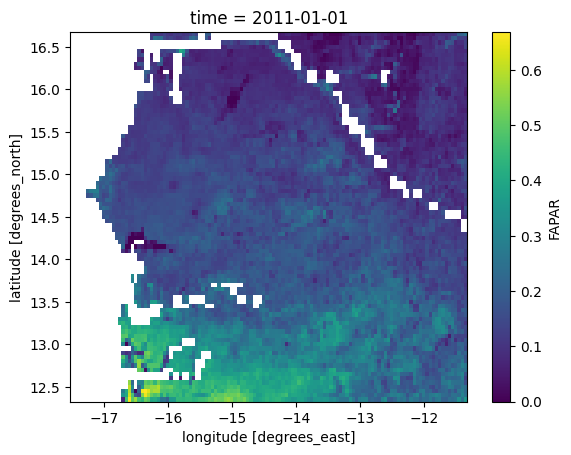

In [14]:
fapar_sen = fapar.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))
fapar_sen["FAPAR"].isel(time=0).plot()

In [15]:
# make it like CDR

half_month = xr.where(fapar_sen['time'].dt.day <= 15,
                      fapar_sen['time'].dt.strftime('%Y-%m-01'),
                      fapar_sen['time'].dt.strftime('%Y-%m-16'))
# print(half_month)
fapar_hm = fapar_sen.assign_coords(half_month=("time", pd.to_datetime(half_month.values)))
fapar_hm

<xarray.Dataset> Size: 473MB
Dimensions:         (time: 2190, lat: 87, lon: 124)
Coordinates:
  * time            (time) datetime64[ns] 18kB 2011-01-01 ... 2016-12-31
  * lon             (lon) float64 992B -17.5 -17.45 -17.4 ... -11.4 -11.35
  * lat             (lat) float64 696B 12.35 12.4 12.45 ... 16.55 16.6 16.65
    half_month      (time) datetime64[ns] 18kB 2011-01-01 ... 2016-12-16
Data variables:
    FAPAR           (time, lat, lon) float64 189MB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
    quality_flag    (time, lat, lon) float32 95MB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
    standard_error  (time, lat, lon) float64 189MB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
Attributes: (12/29)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2020-11-09T17:32:32Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    westernmost_longitude:      80.0
    spatial_resolution:          0.05x 0.05
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

In [16]:
fapar_mean = fapar_hm.groupby('half_month').mean(dim='time')
fapar_mean = fapar_mean.rename({'half_month': 'time'})
fapar_mean

<xarray.Dataset> Size: 31MB
Dimensions:         (time: 144, lat: 87, lon: 124)
Coordinates:
  * lon             (lon) float64 992B -17.5 -17.45 -17.4 ... -11.4 -11.35
  * lat             (lat) float64 696B 12.35 12.4 12.45 ... 16.55 16.6 16.65
  * time            (time) datetime64[ns] 1kB 2011-01-01 ... 2016-12-16
Data variables:
    FAPAR           (time, lat, lon) float64 12MB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
    quality_flag    (time, lat, lon) float32 6MB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
    standard_error  (time, lat, lon) float64 12MB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
Attributes: (12/29)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2020-11-09T17:32:32Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    westernmost_longitude:      80.0
    spatial_resolution:          0.05x 0.05
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

In [19]:
period = (fapar_mean['time'].dt.month - 1)* 2 + xr.where(fapar_mean['time'].dt.day <= 15, 1, 2)

fapar_mean = fapar_mean.assign_coords(period =("time", period.data))
fapar_mean

<xarray.Dataset> Size: 31MB
Dimensions:         (time: 144, lat: 87, lon: 124)
Coordinates:
  * lon             (lon) float64 992B -17.5 -17.45 -17.4 ... -11.4 -11.35
  * lat             (lat) float64 696B 12.35 12.4 12.45 ... 16.55 16.6 16.65
  * time            (time) datetime64[ns] 1kB 2011-01-01 ... 2016-12-16
    period          (time) int64 1kB 1 2 3 4 5 6 7 8 ... 17 18 19 20 21 22 23 24
Data variables:
    FAPAR           (time, lat, lon) float64 12MB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
    quality_flag    (time, lat, lon) float32 6MB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
    standard_error  (time, lat, lon) float64 12MB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
Attributes: (12/29)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2020-11-09T17:32:32Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    westernmost_longitude:      80.0
    spatial_resolution:          0.05x 0.05
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

In [52]:
# # make 5 time step fapar_sen to write as zarr and then append

from data2zarr import write_zarr_from_ds, append_zarr_from_ds

fapar_sen_1 = fapar_sen.isel(time=[0, 1, 2, 3, 4])
fapar_sen_1.close()

In [51]:
print(fapar_sen_1)
print(fapar_sen_1.chunks)
print(fapar_sen_1.dims)

<xarray.Dataset> Size: 1MB
Dimensions:         (time: 5, lat: 87, lon: 124)
Coordinates:
  * time            (time) datetime64[ns] 40B 2011-01-01 ... 2011-01-05
  * lon             (lon) float64 992B -17.5 -17.45 -17.4 ... -11.4 -11.35
  * lat             (lat) float64 696B 12.35 12.4 12.45 ... 16.55 16.6 16.65
Data variables:
    FAPAR           (time, lat, lon) float64 432kB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
    quality_flag    (time, lat, lon) float32 216kB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
    standard_error  (time, lat, lon) float64 432kB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
Attributes: (12/29)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2020-11-09T17:32:32Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    westernmost_longit

In [53]:
write_zarr_from_ds(fapar_sen_1, processed_data_path / 'FAPAR' / 'fapar_sen_1.zarr',
                   extra_attrs={'description': 'FAPAR dataset for Senegal region, subsetted from the original FAPAR dataset',
                                'source': 'FAPAR dataset',
                                'updated_by': 'kzakir',
                                'temporal_resolution': 'daily',
                                'spatial_resolution': '0.05 degrees',
                                'spatial_extent': f'Senegal region, bounding box: {minx}, {miny}, {maxx}, {maxy}'},
                                )


[write] writing ['FAPAR', 'quality_flag', 'standard_error'] to /data/dv-data/cdo_processed/FAPAR/fapar_sen_1.zarr with chunks={'time': 5, 'lat': 87, 'lon': 124} and compressor=BloscCodec(_tunable_attrs={'typesize'}, typesize=1, cname=<BloscCname.zstd: 'zstd'>, clevel=5, shuffle=<BloscShuffle.bitshuffle: 'bitshuffle'>, blocksize=0)
[write] 180.0 KB bytes written to /data/dv-data/cdo_processed/FAPAR/fapar_sen_1.zarr


<xarray.Dataset> Size: 649kB
Dimensions:         (time: 5, lat: 87, lon: 124)
Coordinates:
  * lat             (lat) float64 696B 12.35 12.4 12.45 ... 16.55 16.6 16.65
  * lon             (lon) float64 992B -17.5 -17.45 -17.4 ... -11.4 -11.35
  * time            (time) datetime64[ns] 40B 2011-01-01 ... 2011-01-05
Data variables:
    FAPAR           (time, lat, lon) float32 216kB dask.array<chunksize=(5, 87, 124), meta=np.ndarray>
    quality_flag    (time, lat, lon) float32 216kB dask.array<chunksize=(5, 87, 124), meta=np.ndarray>
    standard_error  (time, lat, lon) float32 216kB dask.array<chunksize=(5, 87, 124), meta=np.ndarray>
Attributes: (12/41)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2026-06-18T15:39:45Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    zarr_version:               3.1.5
    xarray_version:             2025.9.0
    description:                FAPAR dataset for Senegal region, subsetted f...
    updated_by:                 kzakir
    temporal_resolution:        daily
    spatial_extent:             Senegal region, bounding box: -17.54318619, 1...

In [55]:
# append all the other time steps to the zarr file
append_zarr_from_ds(fapar_sen.isel(time=slice(5, None)), processed_data_path / 'FAPAR' / 'fapar_sen_1.zarr')

[append] time dimension length: 5 -> 2190


<xarray.Dataset> Size: 284MB
Dimensions:         (time: 2190, lat: 87, lon: 124)
Coordinates:
  * lat             (lat) float64 696B 12.35 12.4 12.45 ... 16.55 16.6 16.65
  * lon             (lon) float64 992B -17.5 -17.45 -17.4 ... -11.4 -11.35
  * time            (time) datetime64[ns] 18kB 2011-01-01 ... 2016-12-31
Data variables:
    FAPAR           (time, lat, lon) float32 95MB dask.array<chunksize=(5, 87, 124), meta=np.ndarray>
    quality_flag    (time, lat, lon) float32 95MB dask.array<chunksize=(5, 87, 124), meta=np.ndarray>
    standard_error  (time, lat, lon) float32 95MB dask.array<chunksize=(5, 87, 124), meta=np.ndarray>
Attributes: (12/29)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2020-11-09T17:32:32Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    westernmost_longitude:      80.0
    spatial_resolution:          0.05x 0.05
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

In [56]:
# write fapar_mean first 5 time steps to zarr
fapar_mean_1 = fapar_mean.isel(time=[0, 1, 2, 3, 4])
fapar_mean_1.close()

write_zarr_from_ds(fapar_mean_1, processed_data_path / 'FAPAR' / 'fapar_mean_1.zarr',
                   extra_attrs={'description': 'FAPAR mean dataset for Senegal region, subsetted from the original FAPAR dataset. This dataset represents the mean FAPAR values over half-monthly periods.',
                                'source': 'FAPAR dataset',
                                'updated_by': 'kzakir',
                                'temporal_resolution': 'half-monthly',
                                'spatial_resolution': '0.05 degrees',
                                'spatial_extent': f'Senegal region, bounding box: {minx}, {miny}, {maxx}, {maxy}'},
                                )

[write] writing ['FAPAR', 'quality_flag', 'standard_error'] to /data/dv-data/cdo_processed/FAPAR/fapar_mean_1.zarr with chunks={'time': 5, 'lat': 87, 'lon': 124} and compressor=BloscCodec(_tunable_attrs={'typesize'}, typesize=1, cname=<BloscCname.zstd: 'zstd'>, clevel=5, shuffle=<BloscShuffle.bitshuffle: 'bitshuffle'>, blocksize=0)
[write] 271.6 KB bytes written to /data/dv-data/cdo_processed/FAPAR/fapar_mean_1.zarr


<xarray.Dataset> Size: 649kB
Dimensions:         (time: 5, lat: 87, lon: 124)
Coordinates:
  * lat             (lat) float64 696B 12.35 12.4 12.45 ... 16.55 16.6 16.65
  * lon             (lon) float64 992B -17.5 -17.45 -17.4 ... -11.4 -11.35
    period          (time) int64 40B dask.array<chunksize=(5,), meta=np.ndarray>
  * time            (time) datetime64[ns] 40B 2011-01-01 ... 2011-03-01
Data variables:
    FAPAR           (time, lat, lon) float32 216kB dask.array<chunksize=(5, 87, 124), meta=np.ndarray>
    quality_flag    (time, lat, lon) float32 216kB dask.array<chunksize=(5, 87, 124), meta=np.ndarray>
    standard_error  (time, lat, lon) float32 216kB dask.array<chunksize=(5, 87, 124), meta=np.ndarray>
Attributes: (12/41)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2026-06-18T16:02:29Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    zarr_version:               3.1.5
    xarray_version:             2025.9.0
    description:                FAPAR mean dataset for Senegal region, subset...
    updated_by:                 kzakir
    temporal_resolution:        half-monthly
    spatial_extent:             Senegal region, bounding box: -17.54318619, 1...

In [57]:
# append fapar_mean remaining time steps to zarr
append_zarr_from_ds(fapar_mean.isel(time=slice(5, None)), processed_data_path / 'FAPAR' / 'fapar_mean_1.zarr')

[append] time dimension length: 5 -> 144


<xarray.Dataset> Size: 19MB
Dimensions:         (time: 144, lat: 87, lon: 124)
Coordinates:
  * lat             (lat) float64 696B 12.35 12.4 12.45 ... 16.55 16.6 16.65
  * lon             (lon) float64 992B -17.5 -17.45 -17.4 ... -11.4 -11.35
    period          (time) int64 1kB dask.array<chunksize=(5,), meta=np.ndarray>
  * time            (time) datetime64[ns] 1kB 2011-01-01 ... 2016-12-16
Data variables:
    FAPAR           (time, lat, lon) float32 6MB dask.array<chunksize=(5, 87, 124), meta=np.ndarray>
    quality_flag    (time, lat, lon) float32 6MB dask.array<chunksize=(5, 87, 124), meta=np.ndarray>
    standard_error  (time, lat, lon) float32 6MB dask.array<chunksize=(5, 87, 124), meta=np.ndarray>
Attributes: (12/29)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2020-11-09T17:32:32Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    westernmost_longitude:      80.0
    spatial_resolution:          0.05x 0.05
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

In [ ]:
# for var in fapar.data_vars:
#     print(var, fapar[var].attrs)

FAPAR {'long_name': 'FAPAR'}
quality_flag {'long_name': 'Q_FLAGS'}
standard_error {'long_name': 'Error'}


In [ ]:
# %load_ext autoreload
# %autoreload 2
# from "/home/kzakir/dvcube/test/zarr_cube/zarr_local" import plot_sahel_ds, example_dataset_path, check_time_steps
# # call functions or re-import as needed

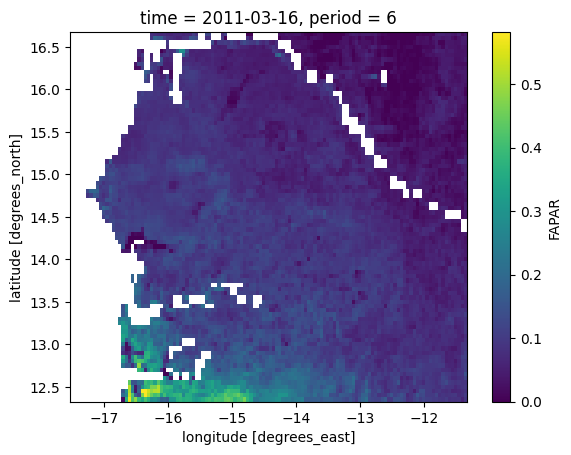

In [22]:
# plot one time step to check
fapar_mean.FAPAR.isel(time=5).plot()

In [ ]:
climatology = fapar_mean.groupby('period').mean('time')
climatology

<xarray.Dataset> Size: 145MB
Dimensions:         (period: 24, lat: 201, lon: 1501)
Coordinates:
  * period          (period) int64 192B 1 2 3 4 5 6 7 8 ... 18 19 20 21 22 23 24
  * lat             (lat) float64 2kB 10.0 10.05 10.1 10.15 ... 19.9 19.95 20.0
  * lon             (lon) float64 12kB -20.0 -19.95 -19.9 ... 54.9 54.95 55.0
Data variables:
    FAPAR           (period, lat, lon) float64 58MB dask.array<chunksize=(1, 1, 1501), meta=np.ndarray>
    quality_flag    (period, lat, lon) float32 29MB dask.array<chunksize=(1, 1, 1501), meta=np.ndarray>
    standard_error  (period, lat, lon) float64 58MB dask.array<chunksize=(1, 1, 1501), meta=np.ndarray>
Attributes: (12/29)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2020-11-09T17:32:32Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    westernmost_longitude:      80.0
    spatial_resolution:          0.05x 0.05
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

In [ ]:
anomaly = fapar_mean.groupby('period') - climatology
anomaly

<xarray.Dataset> Size: 869MB
Dimensions:         (lon: 1501, lat: 201, time: 144)
Coordinates:
  * lon             (lon) float64 12kB -20.0 -19.95 -19.9 ... 54.9 54.95 55.0
  * lat             (lat) float64 2kB 10.0 10.05 10.1 10.15 ... 19.9 19.95 20.0
  * time            (time) datetime64[ns] 1kB 2011-01-01 ... 2016-12-16
    period          (time) int64 1kB 1 2 3 4 5 6 7 8 ... 17 18 19 20 21 22 23 24
Data variables:
    FAPAR           (time, lat, lon) float64 348MB dask.array<chunksize=(1, 1, 1501), meta=np.ndarray>
    quality_flag    (time, lat, lon) float32 174MB dask.array<chunksize=(1, 1, 1501), meta=np.ndarray>
    standard_error  (time, lat, lon) float64 348MB dask.array<chunksize=(1, 1, 1501), meta=np.ndarray>
Attributes: (12/29)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2020-11-09T17:32:32Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    westernmost_longitude:      80.0
    spatial_resolution:          0.05x 0.05
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

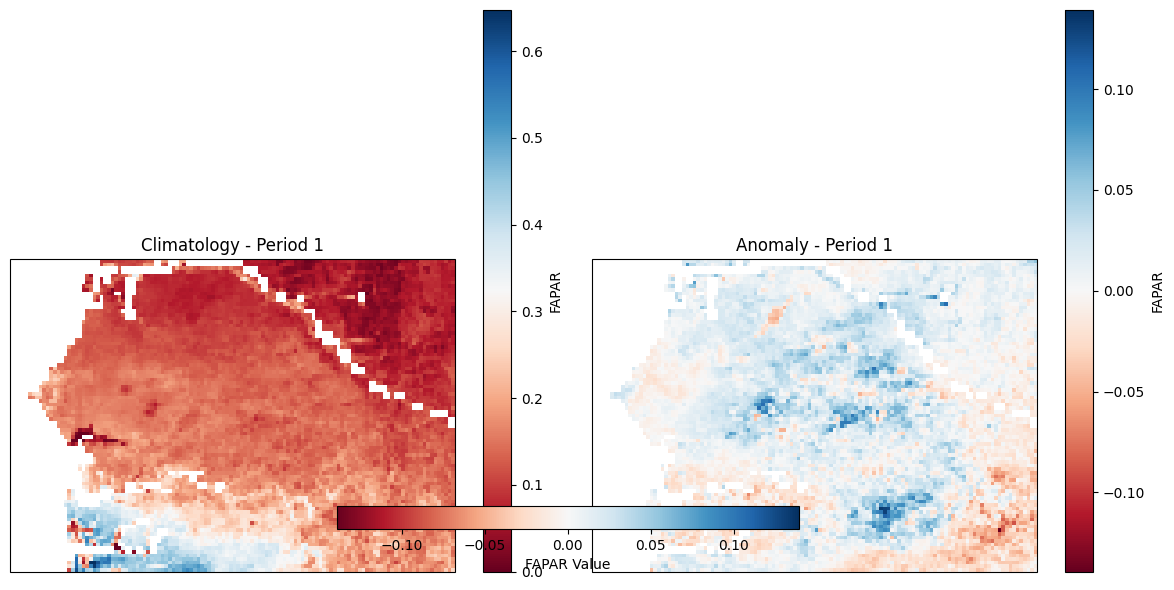

In [ ]:
#climatology and anomaly for one bounding box small area

climatology_bbox = climatology.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))
anomaly_bbox = anomaly.sel(lon=slice(minx, maxx), lat=slice(miny, maxy))
# anomaly_bbox.FAPAR[0].plot()
# climatology_bbox
# plot the climatology and anomaly for the first period
fig, axes = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree()})
climatology_bbox.FAPAR.isel(period=0).plot(ax=axes[0], transform=ccrs.PlateCarree(), cmap='RdBu')
axes[0].set_title('Climatology - Period 1')
anomaly_bbox.FAPAR[0].plot(ax=axes[1], transform=ccrs.PlateCarree(), cmap='RdBu')
axes[1].set_title('Anomaly - Period 1')
# add the color bar horizontally below the plots
cbar = plt.colorbar(axes[1].collections[0], ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('FAPAR Value')
plt.tight_layout()
plt.show()

In [ ]:
# a small lat/lon and time sample for aggregation testing
minx, miny, maxx, maxy = spatial_unit.total_bounds
fapar_sample = fapar_mean.sel(
    lat=slice(miny, maxy),
    lon=slice(minx, maxx)
).isel(time=slice(0, 10))
fapar_sample

<xarray.Dataset> Size: 2MB
Dimensions:         (time: 10, lat: 87, lon: 124)
Coordinates:
  * time            (time) datetime64[ns] 80B 2011-01-01 ... 2011-05-16
  * lat             (lat) float64 696B 12.35 12.4 12.45 ... 16.55 16.6 16.65
  * lon             (lon) float64 992B -17.5 -17.45 -17.4 ... -11.4 -11.35
    period          (time) int64 80B 1 2 3 4 5 6 7 8 9 10
Data variables:
    FAPAR           (time, lat, lon) float64 863kB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
    quality_flag    (time, lat, lon) float32 432kB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
    standard_error  (time, lat, lon) float64 863kB dask.array<chunksize=(1, 1, 124), meta=np.ndarray>
Attributes: (12/29)
    CDI:                        Climate Data Interface version 2.0.4 (https:/...
    Conventions:                CF-1.6
    institution:                IM-PT
    date_created:               2020-11-09T17:32:32Z
    algorithm_version:          1.3.2
    base_algorithm_version:     3.0.1
    ...                         ...
    westernmost_longitude:      80.0
    spatial_resolution:          0.05x 0.05
    geospatial_lat_units:       degrees_north
    geospatial_lon_units:       degrees_east
    netcdf_version_id:          netCDF4
    CDO:                        Climate Data Operators version 2.0.4 (https:/...

In [ ]:
fapar_da = fapar_sample.FAPAR.rio.write_crs('EPSG:4326')
aggregated = fapar_da.xvec.zonal_stats(
    spatial_unit.geometry,
    x_coords='lon',
    y_coords='lat',
    method='exactextract'
)
aggregated

NameError: name 'fapar_sample' is not defined

In [ ]:
print(aggregated.sizes)
print(aggregated.coords)
print(aggregated)

Frozen({'geometry': 151, 'time': 10})
Coordinates:
  * geometry  (geometry) geometry 1kB MULTIPOLYGON (((-17.1400547 14.57827377...
  * time      (time) datetime64[ns] 80B 2011-01-01 2011-01-16 ... 2011-05-16
<xarray.DataArray (geometry: 151, time: 10)> Size: 12kB
array([[0.24447405, 0.21058953, 0.19344012, ..., 0.10199769, 0.11638135,
        0.08188158],
       [0.10457253, 0.08777311, 0.09691957, ..., 0.06908104, 0.06940976,
        0.04604915],
       [0.11661526, 0.09673639, 0.09175874, ..., 0.08266074, 0.08322357,
        0.05851192],
       ...,
       [0.14507197, 0.11244488, 0.1036658 , ..., 0.05289285, 0.05664408,
        0.04661484],
       [0.23149998, 0.15573811, 0.14434171, ..., 0.13227319, 0.1599538 ,
        0.15121452],
       [0.47642019, 0.41615842, 0.4069886 , ..., 0.34054437, 0.38850355,
        0.33507809]], shape=(151, 10))
Coordinates:
  * geometry  (geometry) geometry 1kB MULTIPOLYGON (((-17.1400547 14.57827377...
  * time      (time) datetime64[ns] 80B 2011-01

## NDVI Visualization

Visualize NDVI data over Africa with spatial unit boundaries overlay.

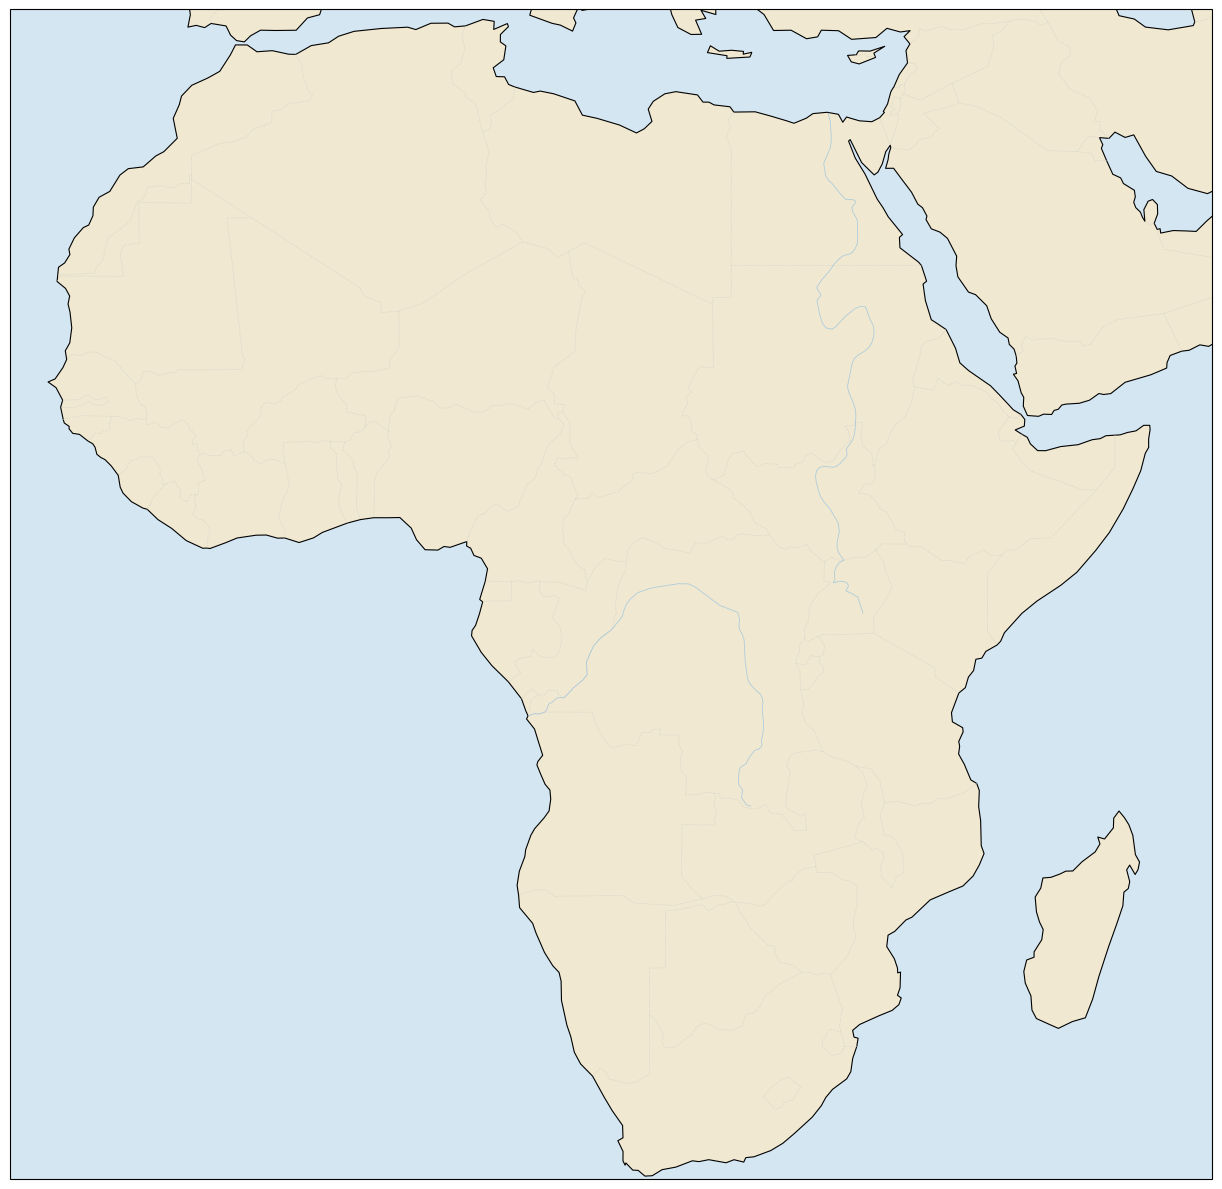

In [9]:
# Full Africa extent
fig, ax = plt.subplots(figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Set full Africa extent
ax.set_extent([-20, 55, -35, 38], crs=ccrs.PlateCarree())

# Add geographic features - clean style
ax.add_feature(cfeature.LAND, facecolor='#f0e8d0', edgecolor='none')
ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1', edgecolor='none')
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, edgecolor='#cccccc', linewidth=0.5, linestyle=':')
ax.add_feature(cfeature.RIVERS, edgecolor='#6eb3e8', linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.savefig('Africa_Full_Extent.png', dpi=150, bbox_inches='tight')
plt.show()

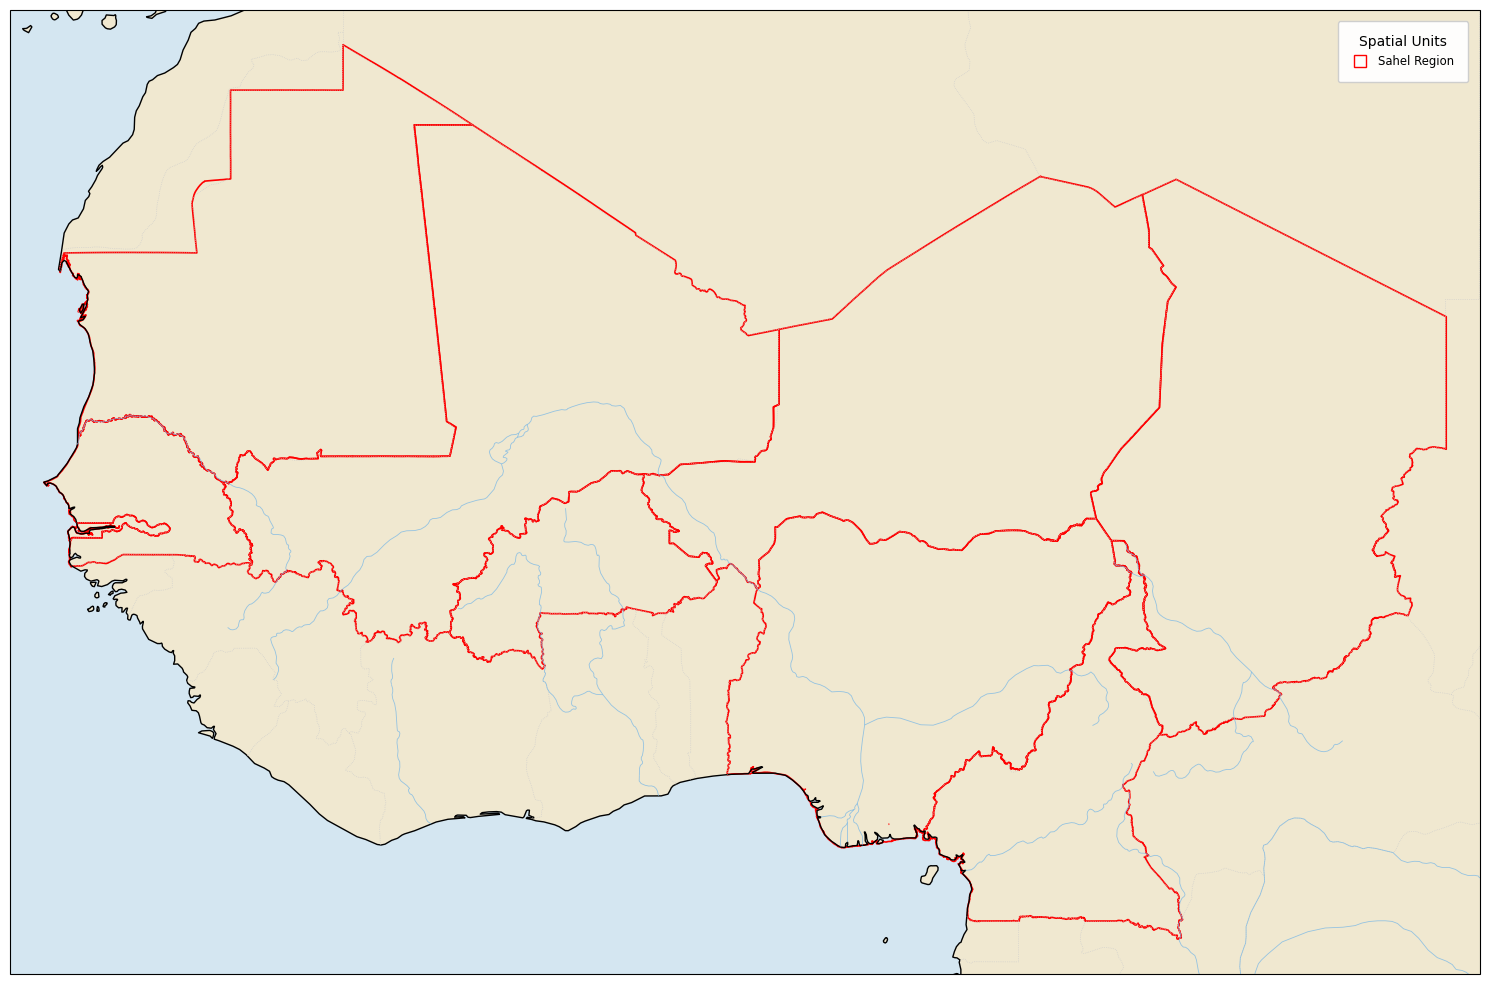

Sahel extent: lon [-17.54, 24.00], lat [1.65, 27.30]


In [10]:
# Sahel region-focused map with boundaries
fig, ax = plt.subplots(figsize=(15, 13), subplot_kw={'projection': ccrs.PlateCarree()})

# Get Sahel bounds and add margin
min_lon_sahel, min_lat_sahel, max_lon_sahel, max_lat_sahel = sahel_boundaries.total_bounds
margin_sahel = 1.0
ax.set_extent([min_lon_sahel - margin_sahel, max_lon_sahel + margin_sahel, 
               min_lat_sahel - margin_sahel, max_lat_sahel + margin_sahel], 
              crs=ccrs.PlateCarree())

# Add geographic features - clean style
ax.add_feature(cfeature.LAND, facecolor='#f0e8d0', edgecolor='none')
ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1', edgecolor='none')
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, edgecolor='#cccccc', linewidth=0.5, linestyle=':')
ax.add_feature(cfeature.RIVERS, edgecolor='#6eb3e8', linewidth=0.6, alpha=0.7)

# Plot Sahel boundaries
sahel_boundaries.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=1.2)

# Plot Senegal boundaries
# senegal_boundaries.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=0.8)

# Add legend with square markers
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='s', color='none', label='Sahel Region',
           markerfacecolor='none', markeredgecolor='red', markersize=8),
#     Line2D([0], [0], marker='s', color='none', label='Senegal Spatial Units',
#            markerfacecolor='none', markeredgecolor='blue', markersize=8),
]
ax.legend(handles=legend_handles,
          loc='upper right',
          fontsize='small',
          title='Spatial Units',
          title_fontsize='medium',
          frameon=True,
          framealpha=0.95,
          borderpad=1.2,
          borderaxespad=1,
          handlelength=1.5,
          handletextpad=0.8,
          columnspacing=1,
          ncol=1)

plt.tight_layout()
plt.savefig('Sahel_Region_Detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Sahel extent: lon [{min_lon_sahel:.2f}, {max_lon_sahel:.2f}], lat [{min_lat_sahel:.2f}, {max_lat_sahel:.2f}]")

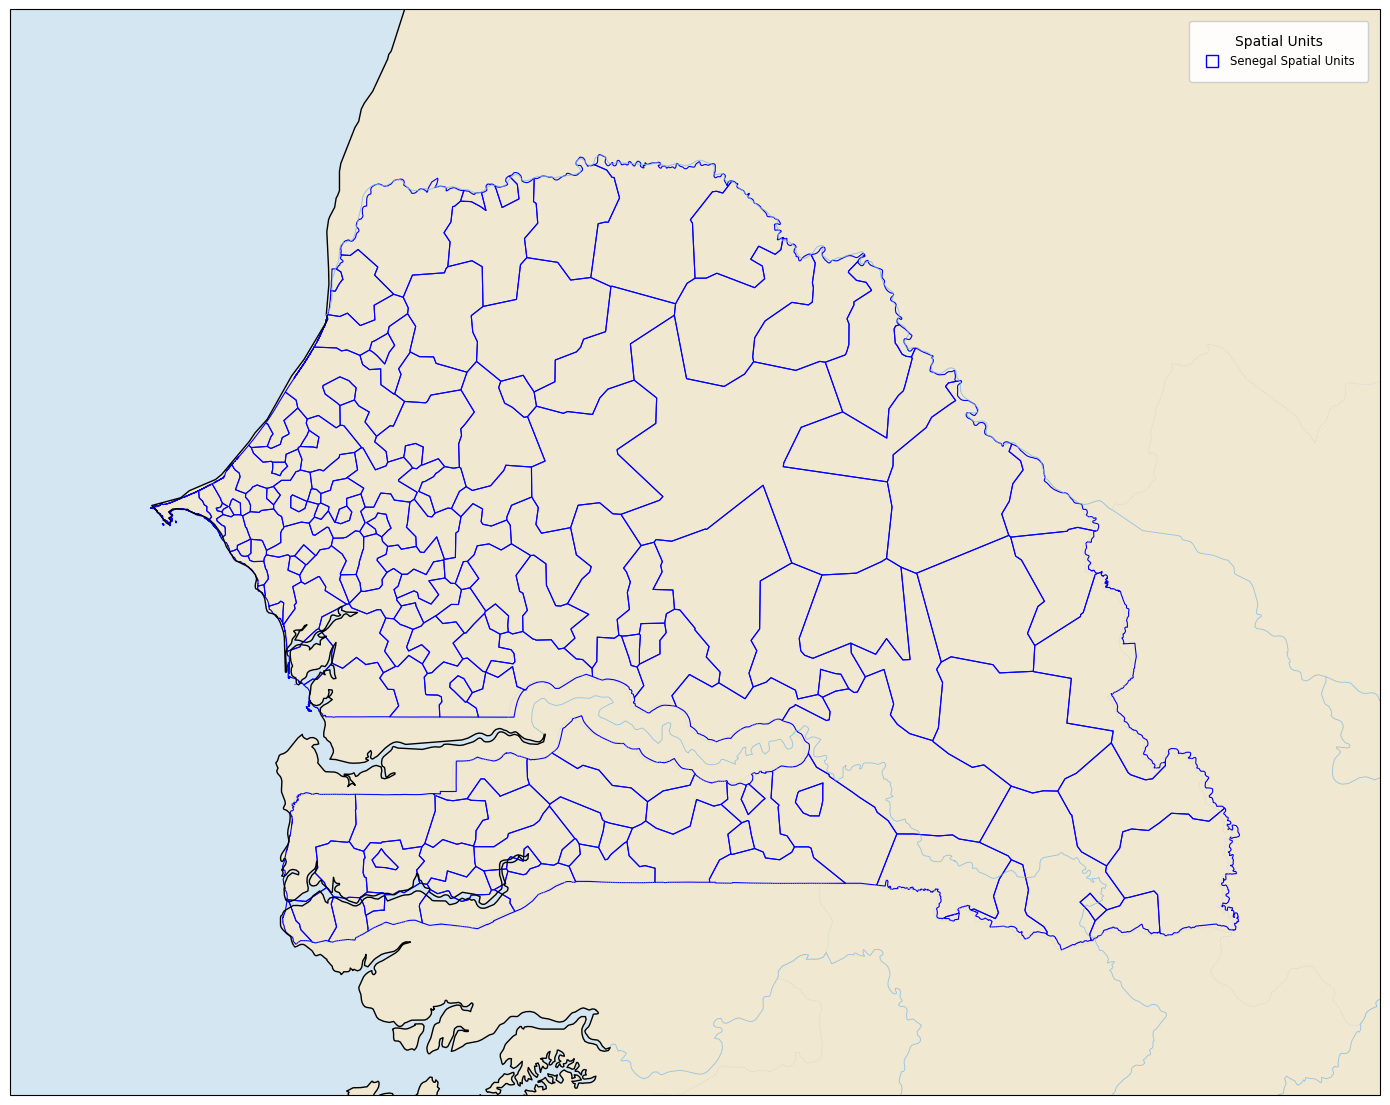

Senegal extent: lon [-17.54, -11.34], lat [12.31, 16.69]


In [11]:
# Senegal-focused map with spatial unit boundaries
fig, ax = plt.subplots(figsize=(14, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Get Senegal bounds and add margin
minx, miny, maxx, maxy = senegal_boundaries.total_bounds
margin = 0.8
ax.set_extent([minx - margin, maxx + margin, miny - margin, maxy + margin], 
              crs=ccrs.PlateCarree())

# Add geographic features - clean style
ax.add_feature(cfeature.LAND, facecolor='#f0e8d0', edgecolor='none')
ax.add_feature(cfeature.OCEAN, facecolor='#d4e6f1', edgecolor='none')
ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, edgecolor='#cccccc', linewidth=0.5, linestyle=':')
ax.add_feature(cfeature.RIVERS, edgecolor='#6eb3e8', linewidth=0.6, alpha=0.7)

# Plot Senegal spatial units
senegal_boundaries.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=0.8)

# Add legend
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='s', color='none', label='Senegal Spatial Units',
           markerfacecolor='none', markeredgecolor='blue', markersize=8),
]
ax.legend(handles=legend_handles,
          loc='upper right',
          fontsize='small',
          title='Spatial Units',
          title_fontsize='medium',
          frameon=True,
          framealpha=0.95,
          borderpad=1.2,
          borderaxespad=1,
          handlelength=1.5,
          handletextpad=0.8)

plt.tight_layout()
plt.savefig('Senegal_Boundaries_Detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Senegal extent: lon [{minx:.2f}, {maxx:.2f}], lat [{miny:.2f}, {maxy:.2f}]")

## MISC

In [ ]:
def combine_evpt_to_zarr(files_with_dates, output_path, chunk_time=30):
    """
    Combine multiple daily evpt NetCDF files into a single Zarr file
    
    Parameters:
    -----------
    files_with_dates : list of tuples
        List of (filepath, date) tuples sorted by date
    output_path : str or Path
        Path to save the combined Zarr file
    chunk_time : int
        Number of time steps per chunk
    """
    import warnings
    warnings.filterwarnings('ignore')
    
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    print(f"Loading {len(files_with_dates)} files...")
    
    # Open all datasets and assign time coordinates
    datasets = []
    times = []
    
    for i, (filepath, date) in enumerate(files_with_dates):
        try:
            ds = xr.open_dataset(filepath, chunks={})
            
            # Add time coordinate
            ds = ds.expand_dims(time=[date])
            ds['time'].encoding['units'] = 'days since 1970-01-01'
            ds['time'].encoding['calendar'] = 'standard'
            
            datasets.append(ds)
            times.append(date)
            
            if (i + 1) % 100 == 0:
                print(f"  Loaded {i + 1}/{len(files_with_dates)} files")
                
        except Exception as e:
            print(f"  Warning: Failed to load {filepath}: {e}")
            continue
    
    print(f"Concatenating {len(datasets)} datasets...")
    
    # Concatenate along time dimension
    combined = xr.concat(datasets, dim='time')
    
    # Update metadata
    combined.attrs.update({
        'title': 'Combined Daily Evapotranspiration Data',
        'description': f'Combined from {len(datasets)} daily files',
        'date_range': f"{times[0].date()} to {times[-1].date()}",
        'source': 'LSA-SAF / EUMETSAT',
        'processing': 'Combined daily files with time dimension'
    })
    
    print(f"Combined dataset shape: {combined.dims}")
    print(f"Time range: {combined.time.values[0]} to {combined.time.values[-1]}")
    
    # Rechunk for efficient storage and access
    print(f"Rechunking with time={chunk_time}...")
    combined = combined.chunk({'time': chunk_time, 'lat': 50, 'lon': 50})
    
    # Save to Zarr
    print(f"Saving to Zarr: {output_path}")
    combined.to_zarr(output_path, mode='w', consolidated=True)
    
    print(f"✓ Successfully saved combined dataset to {output_path}")
    
    return combined

# Combine evpt data
output_zarr = "/data/dv-data/preprocessed/evpt_combined_2013_2015.zarr"
combined_evpt = combine_evpt_to_zarr(evpt_files, output_zarr)


In [ ]:
combine_with_time(file_list, output_path="/data/dv-data/preprocessed/sm_combined_2013_2015.zarr")

In [ ]:
evpt = xr.open_zarr("/data/dv-data/preprocessed/zarr_2013_15/evpt_combined_2013_2015.zarr")
lat = evpt['lat']
lon = evpt['lon']
print(lat.shape, lon.shape)
lat.size


In [ ]:
evpt_grid = evpt['Band1']
evpt_grid

In [ ]:
polygons = gpd.read_file("spatial_units_SciData.gpkg")
polygons["pid"] = polygons.index + 1  # Ensure pid starts from 1
polygons = polygons.to_crs("EPSG:4326")  # Ensure CRS is WGS84
polygons

In [ ]:
from rasterio import features

shapes = ((geom, pid) for geom, pid in zip(polygons.geometry, polygons.pid))
poly_raster = features.rasterize(
    shapes=shapes,
    out_shape=(lat.size, lon.size),
    transform=evpt.rio.transform(),
    dtype=np.int32)

It shows how many pixels are in each spatial unit - and value equals for their id

In [ ]:
poly_da = xr.DataArray(
    data=poly_raster,
    coords={"lat": lat, "lon": lon},
    dims=["lat", "lon"], name="spatial_unit_id")
poly_da


In [ ]:
# Get the bounding box of the polygons
minx, miny, maxx, maxy = polygons.total_bounds

# Create figure with cartopy projection
fig, ax = plt.subplots(figsize=(14, 10), 
                        subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the rasterized spatial units
im = poly_da.plot(ax=ax, 
                   transform=ccrs.PlateCarree(),
                   cmap='BrBG',
                   cbar_kwargs={'label': 'Spatial Unit ID', 'shrink': 0.8})

# Set extent to focus on the polygons
ax.set_extent([minx - 1, maxx + 1, miny - 1, maxy + 1], 
              crs=ccrs.PlateCarree())

# Add polygon boundaries overlay
# polygons.boundary.plot(ax=ax, transform=ccrs.PlateCarree(), 
#                        edgecolor='black', linewidth=1.5, facecolor='none')

# Add coastlines and gridlines
ax.coastlines(resolution='50m', linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.3)

# Add title and labels
ax.set_title('Rasterized Spatial Units for Climate Data', fontsize=14, fontweight='bold')

plt.tight_layout()
# plt.savefig('spatial_units_raster.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Spatial unit ID range: {poly_da.min().values} to {poly_da.max().values}")
print(f"Plot extent: [{minx:.2f}, {maxx:.2f}] x [{miny:.2f}, {maxy:.2f}]")


In [ ]:
evpt_stacked = evpt_grid.stack(pixel=("lat", "lon"))
poly_stacked = poly_da.stack(pixel=("lat", "lon"))
print(poly_stacked.shape, evpt_stacked.shape)


In [ ]:
evpt_with_pid = evpt_stacked.assign_coords(pid="pixel", poly=poly_stacked)
# show values for pid
evpt_with_pid

In [ ]:
evpt_poly = evpt_with_pid.groupby("poly").mean(dim="pixel", skipna=True)
evpt_poly

In [ ]:
# plot the all the rasterized spatial units for one time step on map
time_index = 0  # Change this index to plot different time steps
evpt_time_slice = evpt_grid.isel(time=time_index)
fig, ax = plt.subplots(figsize=(14, 10), 
                        subplot_kw={'projection': ccrs.PlateCarree()})
# Plot the rasterized spatial units
im = evpt_time_slice.plot(ax=ax, 
                   transform=ccrs.PlateCarree(),
                   cmap='viridis',
                   cbar_kwargs={'label': 'Evapotranspiration', 'shrink': 0.8})
# Set extent to focus on the polygons
ax.set_extent([minx - 1, maxx + 1, miny - 1, maxy + 1], 
              crs=ccrs.PlateCarree())   
# Add polygon boundaries overlay
polygons.boundary.plot(ax=ax, transform=ccrs.PlateCarree(), 
                       edgecolor='black', linewidth=1.5, facecolor='none')
# Add coastlines and gridlines
ax.coastlines(resolution='50m', linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.3)
# Add title and labels
ax.set_title(f'Evapotranspiration on {evpt.time.values[time_index]}', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('evpt_time_slice.png', dpi=150, bbox_inches='tight')
plt.show()
